In [14]:
2.9*0.2

0.58

In [ ]:
from typing import List
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import scipy as sp

import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad
from pathlib import Path

name = 'penaltyCheck'
history_fname = f"misc/history-{name}.pkl"
data_folder= f"data-{name}"
if not Path(data_folder).exists():
    Path(data_folder).mkdir(parents=True, exist_ok=True)

import pickle
def save_history(history_dict: dict) -> None:
    """Convenience function to save the history to file."""
    with open(history_fname, "wb") as file:
        pickle.dump(history_dict, file)


def load_history() -> dict:
    """Convenience method to load the history from file."""
    with open(history_fname, "rb") as file:
        history_dict = pickle.load(file)
    return history_dict


def load_2d_array(fp, nx, ny):
    import cv2
    with open(fp, "rb") as f:
        mask = pickle.load(f)
    mask_resized = cv2.resize(mask, dsize=(ny, nx), interpolation=cv2.INTER_CUBIC) 
    
    return mask_resized


n_tantala = 2.036  # Tantala refractive index.

proj_filter_threshold = 0.50  # Threshold value for the projection filter.
eta = proj_filter_threshold  # Threshold value for the projection filter.
FoM_name = "FoM_field"  # Name of the monitor used to compute the objective function.

# Simulation wavelength.
wavelength = 2.923  # Central simulation wavelength (um).
wavelength_width = 0.6  # Simulation bandwidth (um).
num_wavelength_points = 61  # Number of wavelength points within the bandwidth.

max_wavelength = wavelength + wavelength_width / 2
min_wavelength = wavelength - wavelength_width / 2
wavelength_array = np.linspace(min_wavelength, max_wavelength, num_wavelength_points)
freq = td.C_0 / wavelength
freq_array = td.C_0 / wavelength_array
freq_width = 0.5 * (freq_array[0] - freq_array[-1])
run_time = 1000e-15


# Minimum and maximum values for the permittivities.
eps_min = 1.0
eps_max = n_tantala**2
mat_tantala = td.Medium(permittivity=eps_max)  # Tantala material.

min_feature_size = 0.12
filter_radius = min_feature_size

# Geometric parameters.
thickness = 0.8  # Waveguide thickness (um).
wg_width = 1.7  # Waveguide width (um).
wg_length = 1.0  # Waveguide length (um).

# Design region parameters.
gc_width = 8.2  # Grating coupler width (um).
gc_length = 8.2  # Grating coupler length (um).
dr_grid_size = 0.03  # Grid size within the design region (um).


# Buffer layer thickness
border_buffer = 0.15
wg_buffer_length = 0.2
wg_buffer_width = wg_width * 0.6
arm_buffer = 0.25


# Inverse design variables.
dr_num_grid_x = int((gc_length + 2 * border_buffer) / dr_grid_size)
dr_num_grid_y = int((gc_width + 2 * border_buffer) / dr_grid_size / 2.0)
dr_num_grid_border = int(border_buffer / dr_grid_size)
dr_num_grid_tot = int(dr_num_grid_x * dr_num_grid_y)
dr_size_x = dr_num_grid_x * dr_grid_size
dr_size_y = 2 * dr_num_grid_y * dr_grid_size
dr_xx, dr_yy = np.meshgrid(
    np.linspace(-dr_size_x / 2, dr_size_x / 2, dr_num_grid_x),
    np.linspace(0, dr_size_y / 2, dr_num_grid_y),
    indexing='ij'
)
# Position coordinates - Coupler on the left, waveguide on the right
dr_center_x = 0.0
wg_start_x = dr_size_x / 2.0


arm_start_x = - dr_size_x / 2.0
arm_width = 1
arm_separation = 2

# Computational domain size.
pml_spacing = 0.6 * wavelength
sim_size_x = dr_size_x + wg_length + 2 * pml_spacing
sim_size_y = dr_size_y + 2 * pml_spacing
sim_size_z = thickness + 2 * pml_spacing

sim_center_x = wg_length / 2.0  # Center simulation over the total length
sim_center_y = 0.0
sim_center_z = 0.0
sim_min_steps_per_wvl = 15 
effective_inf = 1000

mon_pos_x = wg_start_x + wg_length * 0.75
mon_width = int(3 * wg_width / dr_grid_size) * dr_grid_size
mon_height = int(5 * thickness / dr_grid_size) * dr_grid_size

In [2]:
waveguide = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(wg_start_x, -wg_width/2, -thickness/2),
        rmax=(effective_inf, wg_width/2, thickness/2),
    ),
    medium=mat_tantala,
)


arms = [
    td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-effective_inf, -arm_width-arm_separation/2, -thickness/2),
            rmax=(arm_start_x, -arm_separation/2, thickness/2),
        ),
        medium=mat_tantala,
    ),
    td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-effective_inf, arm_separation/2, -thickness/2),
            rmax=(arm_start_x, arm_width+arm_separation/2, thickness/2),
        ),
        medium=mat_tantala,
    )
]


beam_tilt_angle = 0.0  # tilt angle (degrees).
beam_focus_offset = 0.05  # Distance between the source focus and device (um).
beam_pos_z = thickness / 2 + beam_focus_offset
beam_waist_radius = 2.6210  # Defined waist of the beam
gaussian_beam = td.GaussianBeam(
    center=(dr_center_x, 0, beam_pos_z),
    size=(dr_size_x - 2 * border_buffer, dr_size_y - 2 * border_buffer, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freq_width),
    pol_angle=np.pi/2,
    angle_theta=beam_tilt_angle * np.pi / 180.0,
    direction="-",
    num_freqs=7,
    waist_radius=beam_waist_radius,  # Defined waist of the beam
)

FoM_monitor = td.ModeMonitor(
    center=[mon_pos_x, 0, 0],
    size=[0, mon_width, mon_height],
    freqs=[freq],
    mode_spec=td.ModeSpec(num_modes=1, target_neff=n_tantala),
    name=FoM_name,
)

In [3]:
# connectivity_mask = load_2d_array('connectivity_mask.pkl', dr_num_grid_x, dr_num_grid_y)
import time
def wrapper_im_called(f):
    def wrapper(*args, **kwargs):
        first_arg = args[0] if args else None
        print(first_arg)
        plt.imshow(first_arg, cmap='gray')
        plt.show()
        time.sleep(0.5)
        return f(*args, **kwargs)
    print(f"{f.__name__} called")
    return wrapper

def interface_buffer(params):
    """Introduce a solid frame around the design to enhance fabricability and connectivity."""
    # Create Numpy arrays internally so autograd avoids "item assignment" errors.
    mask_np = np.zeros(params.shape)

    # arms interface 
    mask1 = dr_xx < -dr_size_x/2 + arm_buffer
    mask2 = dr_yy > arm_separation/2
    mask3 = dr_yy < arm_separation/2 + arm_width
    region1 = mask1 & mask2 & mask3

    # waveguide interface 
    # extra thickness on waveguide side
    # mask1 = dr_xx > dr_size_x/2 - wg_buffer_length
    # mask2 = dr_yy < wg_buffer_width/2
    # mask3 = dr_xx > dr_size_x/2 - wg_buffer_length
    # region2 = ~(mask1 & mask2) & mask3
    # region2 = (mask1 & mask2)

    # border interface
    mask1 = np.abs(dr_xx) > dr_size_x/2 - border_buffer
    mask2 = dr_yy > dr_size_y/2 - border_buffer
    region3 = mask1 | mask2


    region = region1 | region3
    # region = region1 | region2 | region3
    mask_np[region] = 1
    # mask_np[0:dr_num_grid_border, :] = 1.0
    # mask_np[dr_num_grid_x - dr_num_grid_border :, :] = 1.0
    # mask_np[:, dr_num_grid_y - dr_num_grid_border :] = 1.0
    # try:
    #     mask_np[connectivity_mask == 1] = 1
    # except Exception as e:
    #     print(f"Error occurred while applying manual filter: {e}")

    mask = anp.array(mask_np)
    # params = np.array(params)
    # params[mask == 1] = eps_max
    return anp.where(mask == 1, eps_max, params)


from tidy3d.plugins.autograd import make_filter_and_project, rescale

filter_project = make_filter_and_project(filter_radius, dr_grid_size, padding="reflect")
def pre_process(params, beta):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0,1)"""
    params = interface_buffer(params)
    params = filter_project(params, beta=beta)
    params = filter_project(params, beta=beta)
    return params

def get_eps_values(params: np.ndarray, beta: float) -> np.ndarray:
    """Get the relative permittivity array given the parameters."""
    params = pre_process(params, beta=beta)
    eps_values = rescale(params, eps_min, eps_max)
    return eps_values

def get_eps(design_param: np.ndarray, beta: float = 1.00, binarize: bool = False) -> np.ndarray:
    """Returns the permittivities for the simulation."""
    eps = get_eps_values(design_param, beta=beta)
    if binarize:
        eps = anp.where(eps < (eps_min + eps_max) / 2, eps_min, eps_max)
    else:
        eps = anp.where(eps < eps_min, eps_min, eps)
        eps = anp.where(eps > eps_max, eps_max, eps)
    return eps

def update_design(eps, unfold: bool = False) -> List[td.Structure]:
    """Reflects the structure about the x-axis. Unfold at final result."""
    nyii = dr_num_grid_y
    y_min = 0
    dr_s_y = dr_size_y / 2
    dr_c_y = dr_s_y / 2
    eps_val = anp.array(eps).reshape((dr_num_grid_x, dr_num_grid_y, 1))
    if unfold:
        nyii = 2 * dr_num_grid_y
        y_min = -dr_size_y / 2
        dr_s_y = dr_size_y
        dr_c_y = 0
        eps_val = anp.concatenate((anp.fliplr(anp.copy(eps_val)), eps_val), axis=1)
        
    # Definition of the coordinates x,y along the design region.
    coords_x = [(dr_center_x - dr_size_x / 2) + ix * dr_grid_size for ix in range(dr_num_grid_x)]
    coords_y = [y_min + iy * dr_grid_size for iy in range(nyii)]
    coords = dict(x=coords_x, y=coords_y, z=[0])

    # Creation of a custom medium using the values of the design parameters.
    permittivity = td.SpatialDataArray(eps_val, coords=coords)
    eps_medium = td.CustomMedium(permittivity=permittivity)
    box = td.Box(center=(dr_center_x, dr_c_y, 0), size=(dr_size_x, dr_s_y, thickness))
    design_structure = td.Structure(geometry=box, medium=eps_medium)
    return [design_structure]

def make_adjoint_sim(
    design_param: np.ndarray,
    beta: float = 1.00,
    unfold: bool = False,
    binarize: bool = False,
) -> td.Simulation:
    # Builds the design region from the design parameters.
    eps = get_eps(design_param, beta, binarize)
    design_structure = update_design(eps, unfold=unfold)

    # Creates a uniform mesh for the design region.
    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, thickness)),
        dl=[dr_grid_size, dr_grid_size, dr_grid_size],
        enforce=True,
    )

    sim = td.Simulation(
        size=[sim_size_x, sim_size_y, sim_size_z],
        center=[sim_center_x, sim_center_y, sim_center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=max_wavelength,
            min_steps_per_wvl=sim_min_steps_per_wvl,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, -1, 0),
        structures=[waveguide] + arms + design_structure,
        sources=[gaussian_beam],
        monitors=[FoM_monitor],
        run_time=run_time,
        subpixel=True,
    )

    return sim

In [4]:

def FoM(sim_data: td.SimulationData) -> float:
    """Return the power at the mode index of interest."""
    output_amps = sim_data[FoM_name].amps
    amp = output_amps.sel(direction="+", f=freq, mode_index=0).values
    return anp.sum(anp.abs(amp) ** 2)


from tidy3d.plugins.autograd import make_erosion_dilation_penalty

erode_dilate_penalty = make_erosion_dilation_penalty(filter_radius, dr_grid_size)
def penalty(params, beta) -> float:
    """Penalty function based on amount of change in parameters after erosion and dilation."""
    rho = pre_process(params, beta=beta)
    return erode_dilate_penalty(rho)


def obj(design_param, beta: float = 1.0, step_num: int = None, verbose: bool = False) -> float:
    global current_FoM, current_penalty
    sim = make_adjoint_sim(design_param, beta)
    task_name = "inv_des"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    
    FoM_val = FoM(sim_data)
    feature_size_penalty = penalty(design_param, beta=beta)
    # conn_penalty = custom_connectivity_penalty(design_param, beta=beta)
    
    current_FoM = FoM_val._value
    current_penalty = feature_size_penalty._value
    J = FoM_val - feature_size_penalty #- 0.5*conn_penalty
    return J

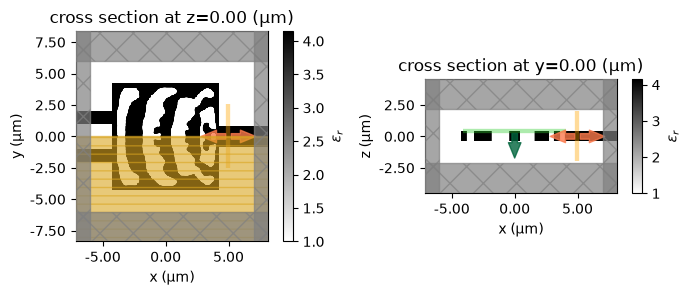

In [5]:
%matplotlib inline
init_params = load_2d_array('seed38-cleaned.pkl', dr_num_grid_x, dr_num_grid_y)
# init_params = np.random.uniform(0, 1, int(dr_num_grid_tot))
# init_params = sp.ndimage.gaussian_filter(init_params.reshape((dr_num_grid_x, dr_num_grid_y)), 2)
init_design = make_adjoint_sim(init_params, beta=10, unfold=True, binarize=False)
fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(7, 7))
init_design.plot_eps(z=0, ax=ax1)
init_design.plot_eps(y=0, ax=ax2)
fig.savefig(f"{data_folder}/init_design.png")
plt.show()

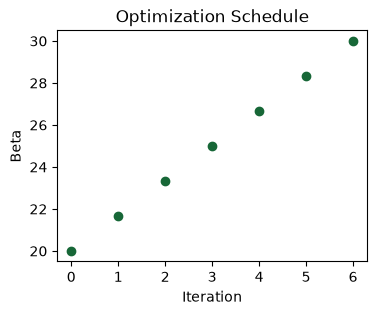

In [6]:

iter_total = 7
beta_min, beta_max = 20, 30
beta_list = np.linspace(beta_min, beta_max, iter_total)
plt.figure(figsize=(4, 3))
plt.scatter(range(iter_total), beta_list)
plt.xlabel('Iteration')
plt.ylabel('Beta')
plt.title('Optimization Schedule')
plt.savefig(f"{data_folder}/optimization_schedule.png")


def printf(*args, **kwargs):
    with open(f"{data_folder}/output.log", "a") as f:
        print(*args, **kwargs, file=f)


print_func = printf
def print_history(history_dict, iter_id):
    outputs = [
        str(iter_id).center(12),
        f"{history_dict['FoM'][iter_id]:.4f}".center(12),
        f"{history_dict['penalty'][iter_id]:.4f}".center(12),
        f"{history_dict['beta'][iter_id]:.4f}".center(12),
        f"{np.linalg.norm(history_dict['gradient'][iter_id]):.3e}".center(12),
        f"{history_dict['objective'][iter_id]:.4f}".center(12)
    ]
    print_func("|" + "|".join(outputs) + "|")

In [11]:
def report_design(iter_idx, params, beta):
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    sim = make_adjoint_sim(params, beta=beta, unfold=True)
    sim.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax)
    fig.savefig(f"{data_folder}/iteration-{iter_idx}.png")
    plt.show(block=False)


def report_final_design(sim_data_fp=f"{data_folder}/simulation_data.hdf5"):
	
	history_dict = load_history()
	obj_vals = np.array(history_dict["objective"])
	penalty = np.array(history_dict["penalty"])
	FoM = np.array(history_dict["FoM"])

	last_params = history_dict["params"][-1]

	field_xy = td.FieldMonitor(
		size=(td.inf, td.inf, 0),
		freqs=[freq],
		name="field_xy",
	)

	field_xz = td.FieldMonitor(
		size=(td.inf, 0, td.inf),
		freqs=[freq],
		name="field_xz",
	)

	# Monitor to compute the grating coupler efficiency.
	gc_efficiency = td.ModeMonitor(
		center=[mon_pos_x, 0, 0],
		size=[0, mon_width, mon_height],
		freqs=freq_array,
		mode_spec=td.ModeSpec(num_modes=1, target_neff=n_tantala),
		name="gc_efficiency",
	)

	sim = make_adjoint_sim(last_params, binarize=True, unfold=True)
	sim = sim.copy(update=dict(monitors=(field_xy, field_xz, gc_efficiency)))
	if Path(sim_data_fp).exists():
		sim_data = td.SimulationData.from_hdf5(sim_data_fp)
	else:
		sim_data = web.run(sim, task_name="inv_des_final")
		sim_data.to_hdf5(sim_data_fp)

	mode_amps = sim_data["gc_efficiency"]
	coeffs_f = mode_amps.amps.sel(direction="+")
	power_0 = np.abs(coeffs_f.sel(mode_index=0)) ** 2
	# power_0_db = 10 * np.log10(power_0)

	fig, ax = plt.subplots(2, 2, figsize=(8, 6), tight_layout=True)
	sim.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax[0, 1])
	# ax[1, 0].plot(wavelength_array, power_0_db, "-k")
	ax[1, 0].plot(wavelength_array, power_0, "-k")
	ax[1, 0].set_xlabel("Wavelength (um)")
	ax[1, 0].set_ylabel("Power (db)")
	# ax[1, 0].set_ylim(-15, 0)
	ax[1, 0].set_xlim(wavelength_array[0], wavelength_array[-1])
	ax[1, 0].set_title("Coupling Efficiency")
	sim_data.plot_field("field_xy", "E", "abs^2", z=0, ax=ax[1, 1])
	ax[0, 0].plot(FoM, "ro-", ms=5, label="FoM")
	ax[0, 0].plot(penalty, "bo-", ms=5, label="Penalty")
	ax[0, 0].plot(obj_vals, "ko-", ms=5, label="Objective")	
	ax[0, 0].set_xlabel("iterations")
	ax[0, 0].set_ylabel("Value")
	ax[0, 0].set_title(f"Learning Curve")
	ax[0, 0].legend()
	fig.savefig(f"{data_folder}/final_results.png")
	sim.to_gds_file(
		f"{data_folder}/final_design.gds", 
		z=0,
		gds_precision=1e-4,
		gds_cell_name="MAIN",
		permittivity_threshold=(eps_max + eps_min) / 2,
		frequency=freq,
	)

def init_history(override):
	history_dict = dict(
			FoM=[],
			penalty=[],
			objective=[],
			params=[],
			beta=[],
			gradient=[],
			opt_state=[],
			data=[],
		)
	if not override:
		try:
			history_dict = load_history()
			print_func("Loaded optimization checkpoint from file.")
			print_func(f"Found {len(history_dict['params'])} iterations previously completed out of {iter_total} total.")
		except FileNotFoundError:
			print_func("Failed to load optimization checkpoint from file.")
	return history_dict
	

def main_loop(override=False):
	from tidy3d.plugins.autograd.optimizers import adam, apply_updates

	learning_rate = 0.2
	optimizer = adam(learning_rate=learning_rate)
	obj_grad = value_and_grad(obj)

	history_dict = init_history(override)
	iter_done = len(history_dict["objective"])
	if iter_done == 0:
		params = np.array(init_params)
		opt_state = optimizer.init(params)
		history_dict["opt_state"].append(opt_state)
	elif iter_done == iter_total:
		print_func("All iterations completed.")

	headers = ['Iteration', 'FoM', 'Penalty', 'Contrast', 'Gradient', 'Objective']
	header_str = "|" + "|".join(h.center(12) for h in headers) + "|"
	printf(header_str)

	for i in range(iter_done):
		printf("-"*len(header_str))
		print_history(history_dict, i)
		
	for i in range(iter_done, iter_total):
		printf("-"*len(header_str))
		beta_i = beta_list[i]
		objective, gradient = obj_grad(params, beta=beta_i)

		updates, opt_state = optimizer.update(-gradient, opt_state, params)
		params[:] = apply_updates(params, updates)

		# cap parameters between 0 and 1
		np.clip(params, 0.0, 1.0, out=params)

		# save history
		history_dict["FoM"].append(current_FoM)
		history_dict["penalty"].append(current_penalty)
		history_dict["objective"].append(objective)
		history_dict["params"].append(params)
		history_dict["beta"].append(beta_i)
		history_dict["gradient"].append(gradient)
		history_dict["opt_state"].append(opt_state)

		save_history(history_dict)
		print_history(history_dict, i)
		report_design(i, params, beta_i)
		
	report_final_design()


19:18:46 Mountain Daylight Time Created task 'inv_des_final' with resource_id   
                                'fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c' and 
                                task_type 'FDTD'.

                                View task using web UI at                       
                                ]8;id=1990978;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=1990979;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\taskI]8;;\
                                ]8;id=1990979;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\d]8;;\]8;id=1990978;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\=]8;;\]8;id=1990980;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\fdve]8;;\]8;id=1990978;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\-0e3b58be-b86f-48ed-b3c3-bc365f06865c']8;;\.

                                Task folder: ]8;id=1990983;https://tidy3d.simulation.cloud/folders/folder-3fb39966-fc96-4a42-a5e3-9ed1e75dd75a\'default']8;;\.

Output()

19:18:47 Mountain Daylight Time Estimated FlexCredit cost: 0.038. This assumes  
                                the FDTD solver runs for the full simulation    
                                time; if early shutoff is reached, the billed   
                                cost can be lower. Use 'web.real_cost(task_id)' 
                                to get the billed FlexCredit cost after a       
                                simulation run.

...

Output()

19:19:25 Mountain Daylight Time status = success

19:19:27 Mountain Daylight Time View simulation result at                       
                                ]8;id=1990986;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=1990987;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\taskI]8;;\
                                ]8;id=1990987;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\d]8;;\]8;id=1990986;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\=]8;;\]8;id=1990988;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\fdve]8;;\]8;id=1990986;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0e3b58be-b86f-48ed-b3c3-bc365f06865c\-0e3b58be-b86f-48ed-b3c3-bc365f06865c']8;;\.

Output()

19:19:28 Mountain Daylight Time Loading results from simulation_data.hdf5

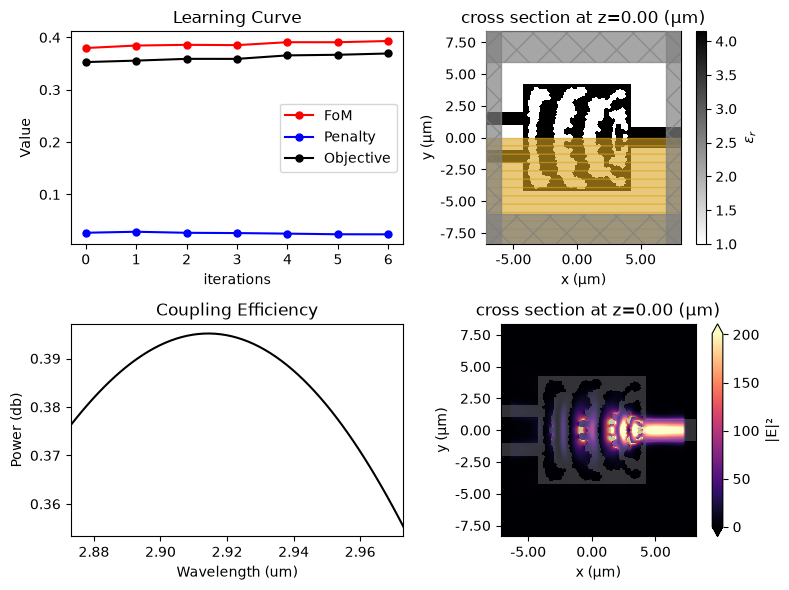

In [12]:
main_loop(override=False)